# 03 — Probabilistic Generative Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Fit a **latent-variable generative model** — a Gaussian Mixture Model (GMM) — by maximum likelihood
- Use **held-out log-likelihood** to evaluate and select between generative models
- **Sample new data** from a fitted probabilistic model and compare it with the real data

## 🔗 Prerequisites

- ✅ Examples 01–02
- ✅ Probability basics: Gaussian distributions, likelihood (Course 03)
- ✅ scikit-learn basics (Course 04)

---

## Introduction

A **probabilistic generative model** writes down p(x) explicitly and fits it by **maximizing likelihood**. The simplest interesting one is the **Gaussian Mixture Model**:

p(x) = Σₖ p(z = k) · p(x | z = k),  with each p(x|z=k) a Gaussian.

Here `z` is a **latent variable** — "which component produced this point?" — which we never observe. This is exactly the structure a VAE (example 04) scales up: the VAE replaces the K discrete components with a continuous latent vector and the Gaussians with neural networks, and maximizes a lower bound (ELBO) on this same log-likelihood.


## Part 1 — Fit by Maximum Likelihood, Evaluate by Held-Out Log-Likelihood

We fit GMMs with 1–5 components and score each in two ways:

- **Held-out log-likelihood** — how much probability the model assigns to *unseen* real data (higher = better). This is the standard way to compare probabilistic generative models.
- **BIC** (Bayesian Information Criterion) — likelihood *minus a penalty for model size* (lower = better). Useful because held-out likelihood often keeps creeping up slightly as you add components; BIC asks whether the extra components pay for themselves.


In [1]:
# WHAT/WHY: fit Gaussian Mixture Models with different numbers of components
# on 2-D data, then use held-out log-likelihood to choose the best model —
# demonstrating that likelihood is both the training signal and the yardstick.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(0)

# ── Build data from 3 true clusters (so we know the right answer is K=3) ──
c1 = rng.normal([-2.0, 0.0],  [0.6, 0.6], size=(400, 2))
c2 = rng.normal([+2.0, 1.0],  [0.9, 0.5], size=(400, 2))
c3 = rng.normal([0.0, -2.5],  [0.5, 0.9], size=(400, 2))
X = np.vstack([c1, c2, c3])
X_tr, X_te = train_test_split(X, test_size=0.3, random_state=0)

# ── Fit K = 1..5; score held-out log-likelihood AND BIC for each ──────────
# Held-out LL rewards fit to unseen data; BIC additionally penalizes model
# size, guarding against "one more component always helps a little".
print("K   held-out avg log-likelihood      BIC (lower = better)")
ll, bic = {}, {}
for k in range(1, 6):
    gmm = GaussianMixture(n_components=k, random_state=0).fit(X_tr)
    ll[k]  = gmm.score(X_te)     # mean log p(x) per held-out point
    bic[k] = gmm.bic(X_tr)       # Bayesian Information Criterion on train
    print(f"{k}          {ll[k]:+.3f}                {bic[k]:,.0f}")

# ── Select K (computed, not assumed): BIC picks the parsimonious model ────
best_k = min(bic, key=bic.get)
print(f"\nBIC selects K = {best_k}; note how held-out log-likelihood jumps up to")
print("K = 3 and then only creeps — extra components buy almost nothing.")
gmm = GaussianMixture(n_components=best_k, random_state=0).fit(X_tr)


K   held-out avg log-likelihood      BIC (lower = better)
1          -3.886                6,579
2          -3.281                5,562
3          -3.083                5,208
4          -3.080                5,248
5          -3.078                5,286

BIC selects K = 3; note how held-out log-likelihood jumps up to
K = 3 and then only creeps — extra components buy almost nothing.


## Part 2 — Generate New Data From the Fitted Model

A fitted probabilistic model is a **generator**: sampling means (1) draw the latent component `z` from its learned weights, then (2) draw x from that component's Gaussian. We plot real vs generated points over the model's learned density.


Samples drawn per latent component z: [133, 128, 139]


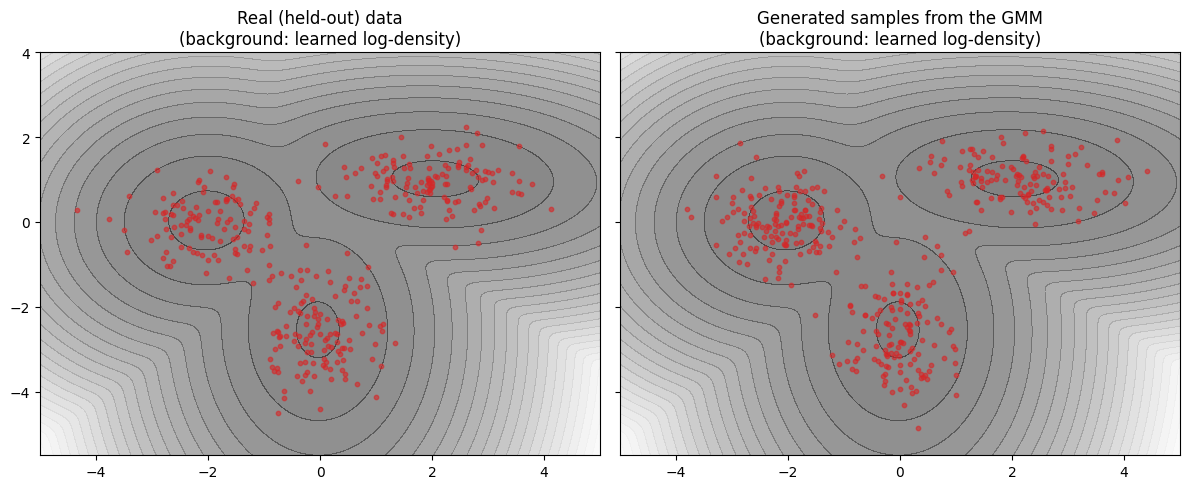


Sampling procedure: draw latent z ~ learned weights, then x ~ Gaussian(z).
A VAE (example 04) does exactly this with a continuous z and neural networks.


In [2]:
# WHAT/WHY: sample brand-new points from the fitted GMM and compare them with
# the real data on top of the model's learned density — the visual test of a
# generative model: do its samples look like the data?

# ── Sample 400 new points; .sample also returns each point's latent z ─────
X_new, z_new = gmm.sample(400)
counts = np.bincount(z_new, minlength=gmm.n_components)
print("Samples drawn per latent component z:", counts.tolist())

# ── Evaluate the learned density p(x) on a grid for the background ────────
xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5.5, 4, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
log_dens = gmm.score_samples(grid).reshape(xx.shape)  # log p(x) at each grid point

# ── Plot: real data (left) vs generated data (right), same density map ────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, pts, title in [(axes[0], X_te, "Real (held-out) data"),
                       (axes[1], X_new, "Generated samples from the GMM")]:
    ax.contourf(xx, yy, log_dens, levels=20, cmap="Greys", alpha=0.5)
    ax.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.6, c="tab:red")
    ax.set_title(title + "\n(background: learned log-density)")
plt.tight_layout(); plt.show()

print("\nSampling procedure: draw latent z ~ learned weights, then x ~ Gaussian(z).")
print("A VAE (example 04) does exactly this with a continuous z and neural networks.")


## From GMM to VAE

| | GMM (this notebook) | VAE (example 04) |
|---|---|---|
| Latent variable | discrete z ∈ {1..K} | continuous vector z |
| p(x\|z) | fixed-form Gaussian | neural network decoder |
| Inference | exact (EM algorithm) | learned encoder + reparameterization |
| Objective | exact log-likelihood | ELBO (a lower bound on log-likelihood) |

Keep the held-out log-likelihood idea in mind: it returns in example 10 as the basis of evaluation metrics for generative models.


## 📚 References & Further Reading

**Textbooks:**
- Bishop (2006) — *Pattern Recognition and Machine Learning*, Ch. 9 (Mixture Models and EM)
- Goodfellow, Bengio & Courville (2016) — [Deep Learning Book](https://www.deeplearningbook.org/), Ch. 20 (Deep Generative Models)

**Papers:**
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114) *(the VAE — the deep version of this notebook's idea)*


## 📝 Summary

In this notebook you fitted a **Gaussian Mixture Model** — a genuine latent-variable generative model — by maximum likelihood, compared models with **held-out log-likelihood and BIC** (check the printed table: likelihood jumps up to K = 3, then flattens, and BIC penalizes the extra components), and **sampled new data** from the fitted model. These are the same three moves (fit p(x), evaluate likelihood, sample) that every deep generative model in this course repeats at scale.
